In [7]:
import pandas as pd
import numpy as np
import matplotlib. pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\thara\Desktop\marketing_AB.csv")
print("shape:", df.shape)
df.head()

shape: (588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [9]:
# AVG OF THE TEST GROUP
df.groupby('test group')['converted'].mean() * 100

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64

In [10]:
# TOTAL COUNT OF USERS
df.groupby('test group')['converted'].count()

test group
ad     564577
psa     23524
Name: converted, dtype: int64

In [11]:
# SUM OF EACH GROUP
df.groupby('test group')['converted'].sum()

test group
ad     14423
psa      420
Name: converted, dtype: int64

In [12]:
from scipy.stats import chi2_contingency

In [13]:
contingency_table = pd.crosstab(df['test group'], df['converted'])
print(contingency_table)

converted    False  True 
test group               
ad          550154  14423
psa          23104    420


In [14]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("chi-square value:", round(chi2, 4))
print("p-value:", round(p_value,10))
print("Degree of Freedom:", dof)

chi-square value: 54.0058
p-value: 0.0
Degree of Freedom: 1


In [15]:
Ad_conversion_rate = df[df['test group']== 'ad'] ['converted'].mean()
PSA_conversion_rate = df[df['test group']== 'psa'] ['converted'].mean()
Lift =(Ad_conversion_rate - PSA_conversion_rate) / PSA_conversion_rate * 100
print(Lift)

43.085064022225836


In [16]:
import statsmodels.stats.proportion as smp

In [17]:
ad_converted = df[df['test group'] == 'ad'] ['converted'].sum()
ad_total = df[df['test group'] == 'ad'] ['converted'].count()
print(ad_converted)
print(ad_total)

14423
564577


In [18]:
ci_low, ci_high = smp.proportion_confint(ad_converted, ad_total, alpha=0.05)
print(f"Ad Group Confidence Interval: {round(ci_low*100,2)}% to {round(ci_high*100,2)}%")

Ad Group Confidence Interval: 2.51% to 2.6%


In [19]:
print('Ad group std:', round(df[df['test group'] == 'ad'] ['converted'].std(),4))
print('PSA group std:', round(df[df['test group'] == 'psa'] ['converted'].std(),4))

Ad group std: 0.1578
PSA group std: 0.1324


In [20]:
correlation = df[['total ads','converted']].corr()
print(correlation)

           total ads  converted
total ads   1.000000   0.217419
converted   0.217419   1.000000


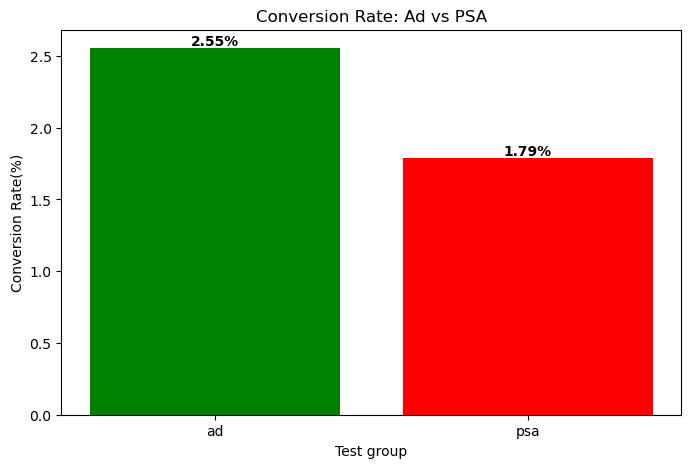

In [29]:
plt.figure(figsize =(8,5))
conversion_rates = df.groupby('test group')['converted'].mean()*100
plt.bar(conversion_rates.index, conversion_rates.values)
plt.title('Conversion Rate: Ad vs PSA')
colors = ['green','red']
plt.bar(conversion_rates.index, conversion_rates.values, color=colors)
plt.xlabel('Test group')
plt.ylabel('Conversion Rate(%)')
for i, val in enumerate(conversion_rates.values):
    plt.text(i,val + 0.02, f'{val:.2f}%',ha='center', fontweight='bold')
plt.savefig('chart1_Conversion_Rate_Ad_vs_PSA.png', bbox_inches='tight', dpi=150)
plt.show()

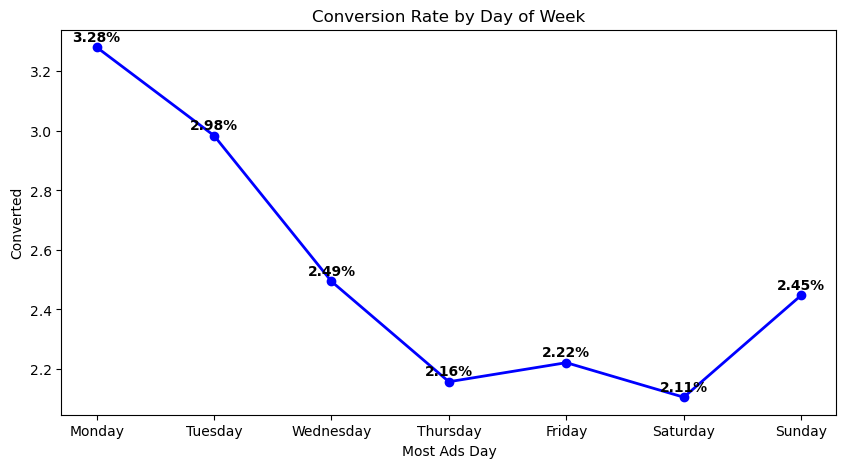

In [30]:
plt.figure(figsize=(10,5))
conversion_rates = df.groupby('most ads day')['converted'].mean() * 100
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
x= conversion_rates.reindex(day_order)
plt.plot(x.index, x.values, marker='o', color = 'blue', linewidth = 2)
plt.title('Conversion Rate by Day of Week')
plt.xlabel('Most Ads Day')
plt.ylabel('Converted')
for i, val in enumerate(x.values):
    plt.text(i,val + 0.02, f'{val:.2f}%',ha='center', fontweight='bold')
plt.savefig('chart2_Conversion_Rate_by_Day_of_Week.png', bbox_inches='tight', dpi=150)
plt.show()

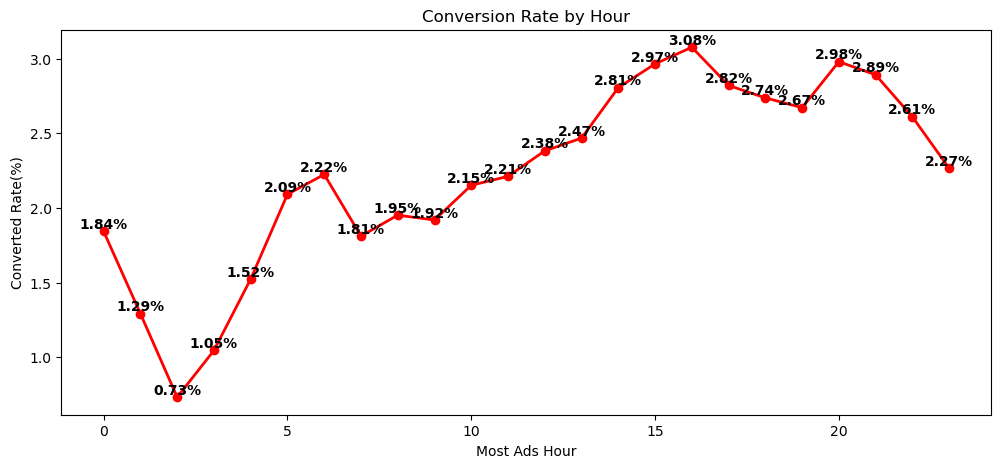

In [31]:
plt.figure(figsize=(12,5))
conversion_rates = df.groupby('most ads hour')['converted'].mean() * 100
plt.plot(conversion_rates.index, conversion_rates.values, marker='o', color = 'red', linewidth = 2)
plt.title('Conversion Rate by Hour')
plt.xlabel('Most Ads Hour')
plt.ylabel('Converted Rate(%)')
for i, val in enumerate(conversion_rates.values):
    plt.text(i,val + 0.02, f'{val:.2f}%',ha='center', fontweight='bold')
plt.savefig('chart3_Conversion_Rate_by_Hour.png', bbox_inches='tight', dpi=150)
plt.show()

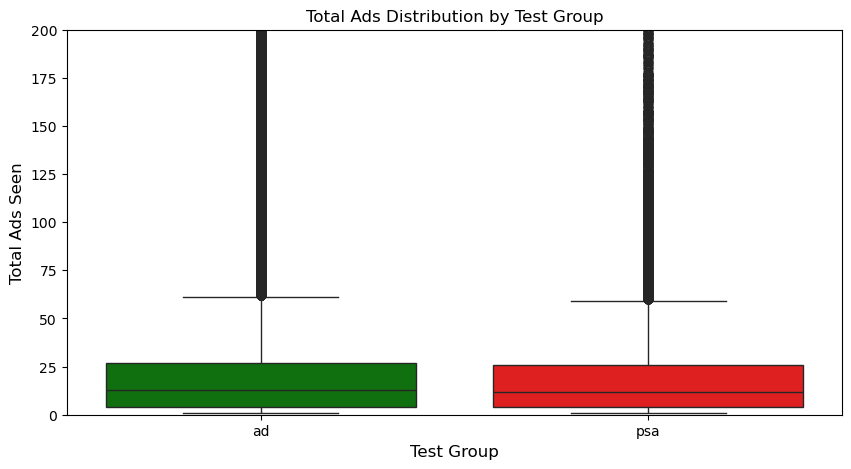

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(x='test group', y ='total ads', hue = 'test group', data=df, palette = ['green','red'], legend = False)
plt.title('Total Ads Distribution by Test Group')
plt.xlabel('Test Group', fontsize = 12)
plt.ylabel('Total Ads Seen', fontsize = 12)
plt.ylim(0,200)
plt.savefig('chart4_Total_Ads_Distribution_by_Group.png', bbox_inches='tight', dpi=150)
plt.show()

In [25]:
df['ads_group'] = pd.cut( df['total ads'],
                          bins = [0, 10, 50, 100, float('inf')],
                          labels = ['0-10', '11-50', '51-100', '100+'],
                        include_lowest = True)

C:\Users\thara\AppData\Local\Temp\ipykernel_4920\1963550296.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_rates = df.groupby('ads_group')['converted'].mean()*100


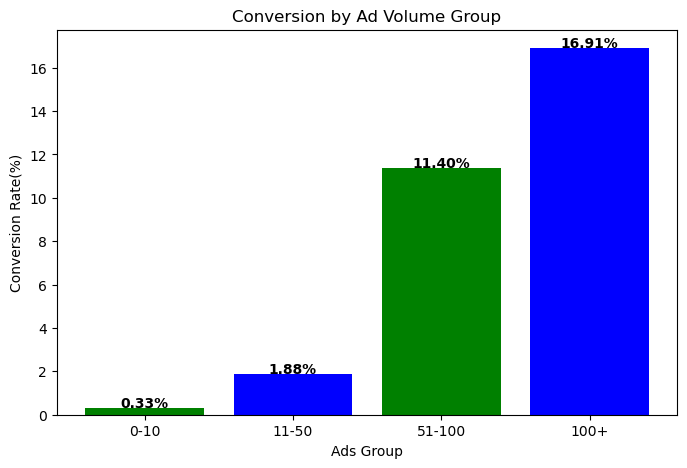

In [33]:
plt.figure(figsize =(8,5))
conversion_rates = df.groupby('ads_group')['converted'].mean()*100
plt.bar(conversion_rates.index, conversion_rates.values)
plt.title('Conversion by Ad Volume Group')
colors = ['green','blue']
plt.bar(conversion_rates.index, conversion_rates.values, color=colors)
plt.xlabel('Ads Group')
plt.ylabel('Conversion Rate(%)')
for i, val in enumerate(conversion_rates.values):
    plt.text(i,val + 0.02, f'{val:.2f}%',ha='center', fontweight='bold')
plt.savefig('chart5_Conversion_by_Ad_Volume_Group.png', bbox_inches='tight', dpi=150)
plt.show()

In [34]:
chi2 = chi2
p_value = p_value
Lift = Lift
ci_low = ci_low
ci_high = ci_high

summary_df = pd.DataFrame({
    'Metric': ['Chi-square', 'P-value', 'Lift', 'Confidence Interval'],
    'Value': [f'{chi2:.4f}',
              f'{p_value:.4f}',
              f'{Lift:.3f}',
              f'{ci_low*100:.2f}% to {ci_high*100:.2f}%']})
summary_df.set_index('Metric',inplace = True)
plt.savefig('Statistical_Summary_Table.png', bbox_inches='tight', dpi=150)
print(summary_df)

                              Value
Metric                             
Chi-square                  54.0058
P-value                      0.0000
Lift                         43.085
Confidence Interval  2.51% to 2.60%


<Figure size 640x480 with 0 Axes>

In [28]:
print("=" * 60)
print("    MARKETING A/B TEST ANALYSIS - KEY INSIGHTS")
print("=" * 60)

print("\n📊 STATISTICAL RESULTS:")
print(f"* Chi-Square Value    : 54.0058")
print(f"* P-Value             : 0.0 (<0.05 - Statistically Significant)")
print(f"* Lift                : 43.09%")
print(f"* Confidence Interval : 2.51% to 2.60%")

print("\n💡 KEY INSIGHTS:")
print("1. Ad campaign is statistically proven to work")
print("   P-value = 0.0 confirms difference is not random chance")
print("2. Real ad performs 43% better that PSA group")
print("   Ad group: 2.55% vs PSA group: 1.79% conversion rate")
print("3. Monday has highest conversion rate at 3.28%")
print("   Tuesday follow at 2.98% - weekdays outperform weekends")
print("4. Hour 16 (4PM) has peak conversion rate 3.08%")
print("   Early morning hours (1-3AM) perform worst at below 1%")
print("5. Users seeing 100+ ads convert at 16.91%")
print("   VS only 0.33% for users seeing 0-10 ads")
print("6. Both ad and PSA groups see similar number of ads")
print("   (median ~13 ads each) - higher conversion in ad group")
print("   is due better ad content, not ad frequency")

print("\n✅ RECOMMENDATION:")
print("1. Continue and scale the real ad campaign")
print("2. Focus ad spend on Monday and Tuesday")
print("3. Schedule ads between 2PM-5PM for maximum impact")
print("4. Increase ad frequency - more exposure = higher conversion")
print("5. Reduce PSA budget - real ads clearly outperform")
print("6. Invest in better ad cretive content rather that")
print("   just increasing ad frequency")

print("\n" + "=" * 60)


    MARKETING A/B TEST ANALYSIS - KEY INSIGHTS

📊 STATISTICAL RESULTS:
* Chi-Square Value    : 54.0058
* P-Value             : 0.0 (<0.05 - Statistically Significant)
* Lift                : 43.09%
* Confidence Interval : 2.51% to 2.60%

💡 KEY INSIGHTS:
1. Ad campaign is statistically proven to work
   P-value = 0.0 confirms difference is not random chance
2. Real ad performs 43% better that PSA group
   Ad group: 2.55% vs PSA group: 1.79% conversion rate
3. Monday has highest conversion rate at 3.28%
   Tuesday follow at 2.98% - weekdays outperform weekends
4. Hour 16 (4PM) has peak conversion rate 3.08%
   Early morning hours (1-3AM) perform worst at below 1%
5. Users seeing 100+ ads convert at 16.91%
   VS only 0.33% for users seeing 0-10 ads
6. Both ad and PSA groups see similar number of ads
   (median ~13 ads each) - higher conversion in ad group
   is due better ad content, not ad frequency

✅ RECOMMENDATION:
1. Continue and scale the real ad campaign
2. Focus ad spend on Monday